In [1]:
# 📦 Step 1: Install dependencies
!pip install ultralytics roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.4 MB/s eta 0:00:00


In [2]:
# 🔑 Step 2: Authenticate Roboflow and download dataset
from roboflow import Roboflow
rf = Roboflow(api_key="Gj8xhF2AnM1mDaya6bh3")  # <-- Replace with your Roboflow API key
project = rf.workspace("simon-kissing-festq").project("household-items-1381x")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Household-items-1 in yolov11:: 100%|██████████| 15564/15564 [00:02<00:00, 5687.06it/s]


In [3]:
# 🧠 Step 3: Train additively from base yolov11n.pt
!yolo task=detect mode=train \
    model=yolo11m.pt \
    data=/content/Household-items-1/data.yaml \
    epochs=20 \
    batch=16 \
    imgsz=640 \
    lr0=0.001 \
    name=kitchen-finetune \
    patience=10 \
    device=0

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Household-items-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

In [4]:
# 📊 Step 4: Validate the trained model
!yolo task=detect mode=val \
    model=runs/detect/kitchen-finetune/weights/best.pt \
    data=/content/Household-items-1/data.yaml \
    split=test

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,039,284 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1604.1±692.3 MB/s, size: 45.4 KB)
val: Scanning /content/Household-items-1/test/labels... 777 images, 11 backgrounds, 0 corrupt: 100% 777/777 [00:00<00:00, 1670.07it/s]
val: New cache created: /content/Household-items-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 49/49 [00:24<00:00,  2.03it/s]
                   all        777       2085      0.681      0.512      0.593      0.426
                   bed        107        124       0.66      0.508      0.554      0.348
                 chair        215        555      0.678      0.319      0.411      0.266
                 couch        119        155      0.697      0.386      0.536      0.378
          dining table        177        217       0.66      0

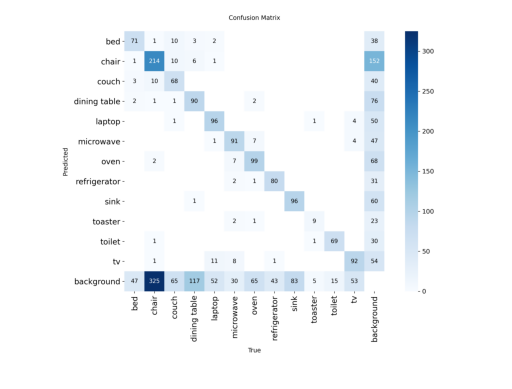

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display image
img = mpimg.imread("runs/detect/val/confusion_matrix.png")
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()